<a href="https://colab.research.google.com/github/Shinyhunter95/Project-6070/blob/main/Project_6070.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import files
uploaded = files.upload()

# Country =	Czechoslovakia
# Station =	Decin
# River =	Elbe
# Area =	51104 km2
# Lat =	50.78
# Lon =	14.22
# Source =	RivDIS
# PointID =	1240
# Area Units =	km2
# Discharge Units =	m3/sec
# Starting Year =	1851
# Ending Year =	1984
# Total Years =	134
# Total Usable Years =	134


Saving elbe.txt to elbe (1).txt


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("elbe.txt", sep="\t")
N = len(df)


# Averages and Standard Deviations (Stripped from the data for easier loading.)
avg = [319.62, 391.22, 520.19, 496.91, 344.51, 258.57, 222.2, 198.86, 191.3, 206.13, 222.32, 274.12]
std_dev = [220.25, 242.21, 265.89, 255.82, 166.29, 170.13, 148.07, 128.76, 150.68, 123.26, 141.57, 188.95]

annual_avg = 303.83
annual_std = 90.5

df_avg = pd.DataFrame(avg, columns=['Avg'])
df_std = pd.DataFrame(std_dev, columns=['Std Dev'])

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


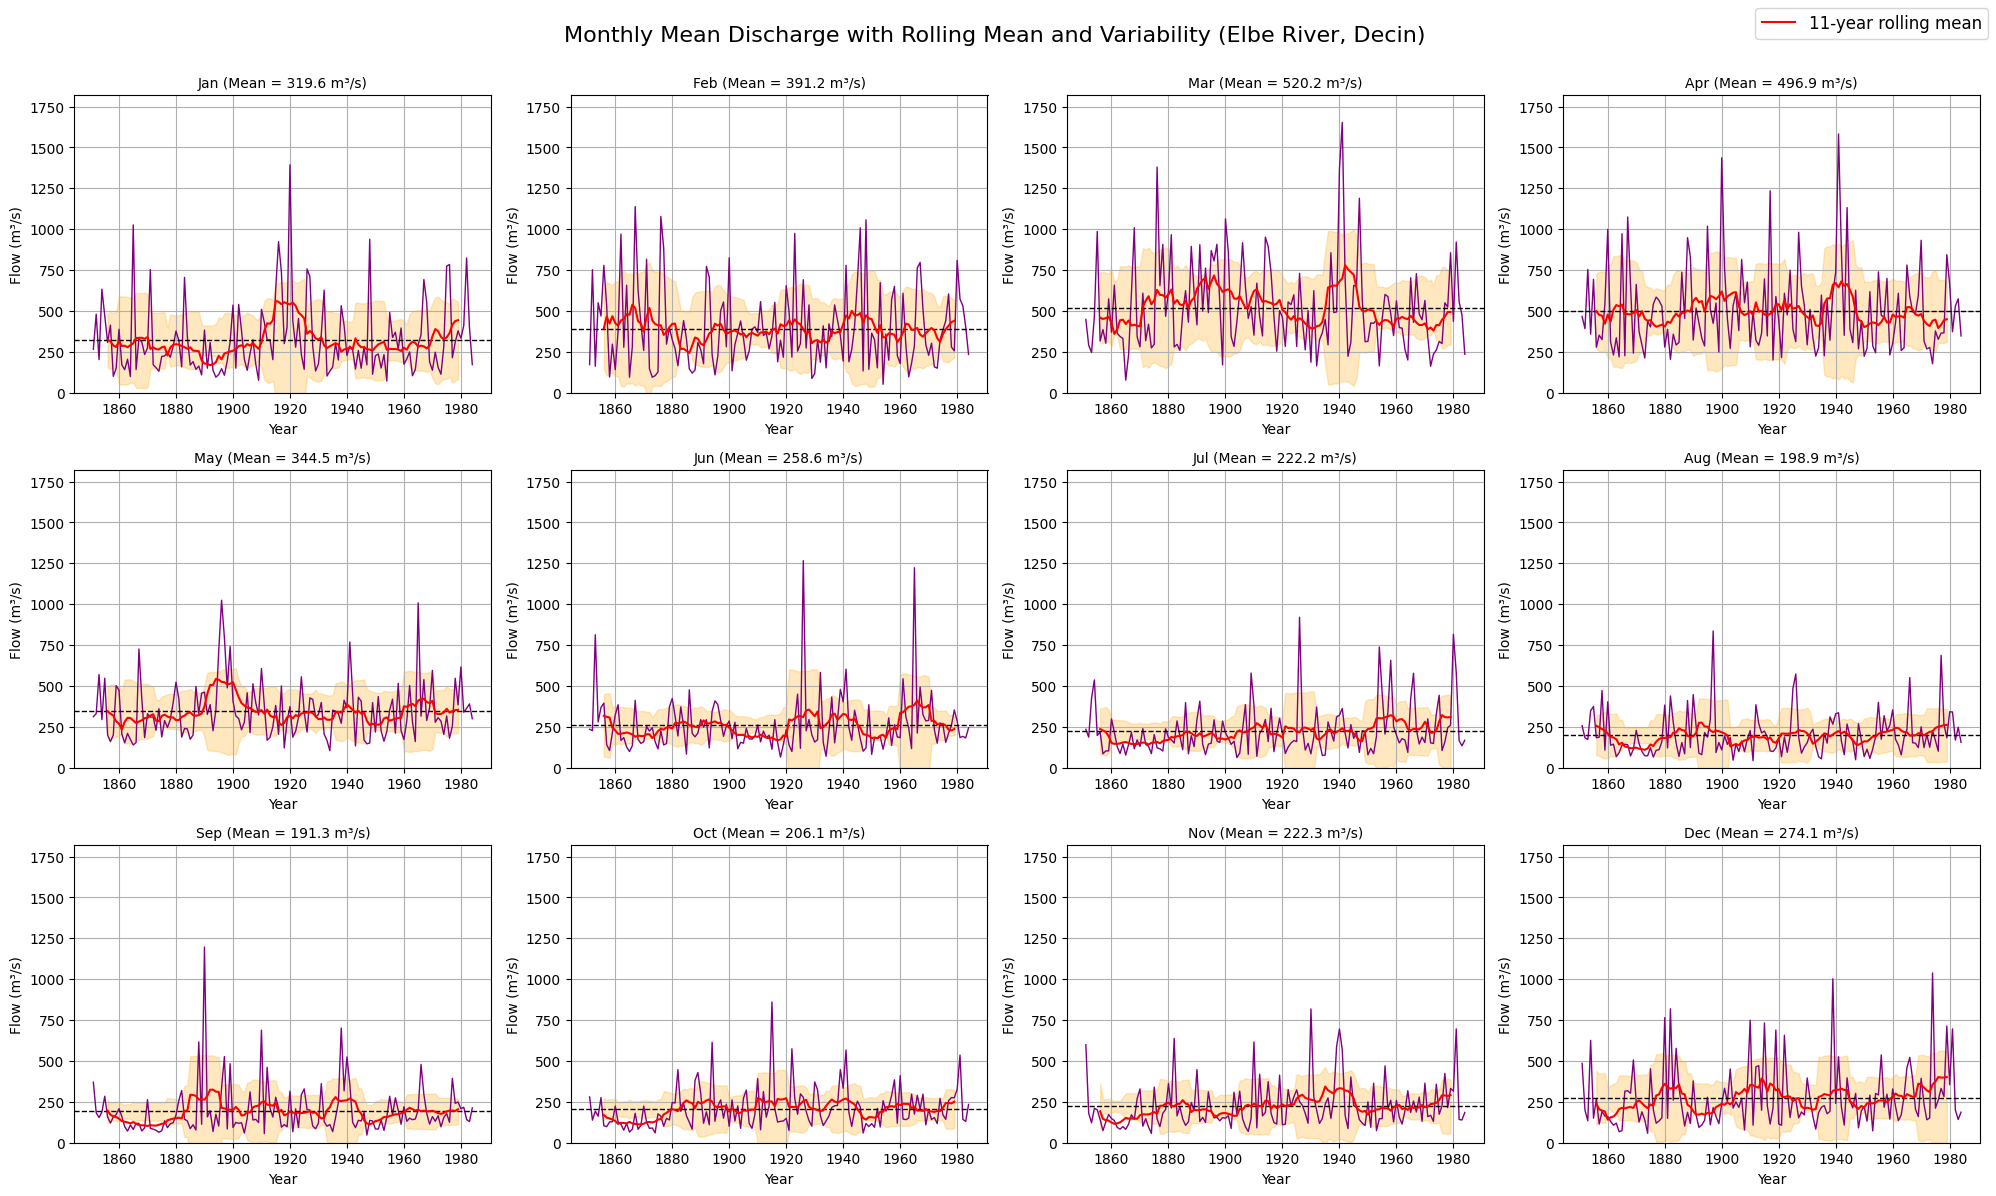

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

window = 11  # rolling window in years

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month]

    # Plot monthly data
    axes[idx].plot(df["Year"], data, color='purple', linewidth=1)

    # Add long-term mean line
    axes[idx].axhline(avg[idx], color='black', linestyle='--', linewidth=1)

    # Compute and plot rolling mean
    rolling_mean = data.rolling(window=window, center=True).mean()
    axes[idx].plot(df["Year"], rolling_mean, color='red', linewidth=1.5, label=f'{window}-year rolling mean')

    # Compute and shade rolling std deviation
    rolling_std = data.rolling(window=window, center=True).std()
    axes[idx].fill_between(
        df["Year"],
        avg[idx] - rolling_std,
        avg[idx] + rolling_std,
        color='orange',
        alpha=0.25
    )

    # Subplot title including mean
    axes[idx].set_title(f"{month} (Mean = {avg[idx]:.1f} m³/s)", fontsize=10)

    # Axis labels
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("Flow (m³/s)")
    axes[idx].grid(True)

    # Uniform y-axis for easier seasonal comparison
    axes[idx].set_ylim(0, max(df[months].max()) * 1.1)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Main figure title
plt.suptitle("Monthly Mean Discharge with Rolling Mean and Variability (Elbe River, Decin)", fontsize=16)

# Figure-level legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=12)

plt.show()

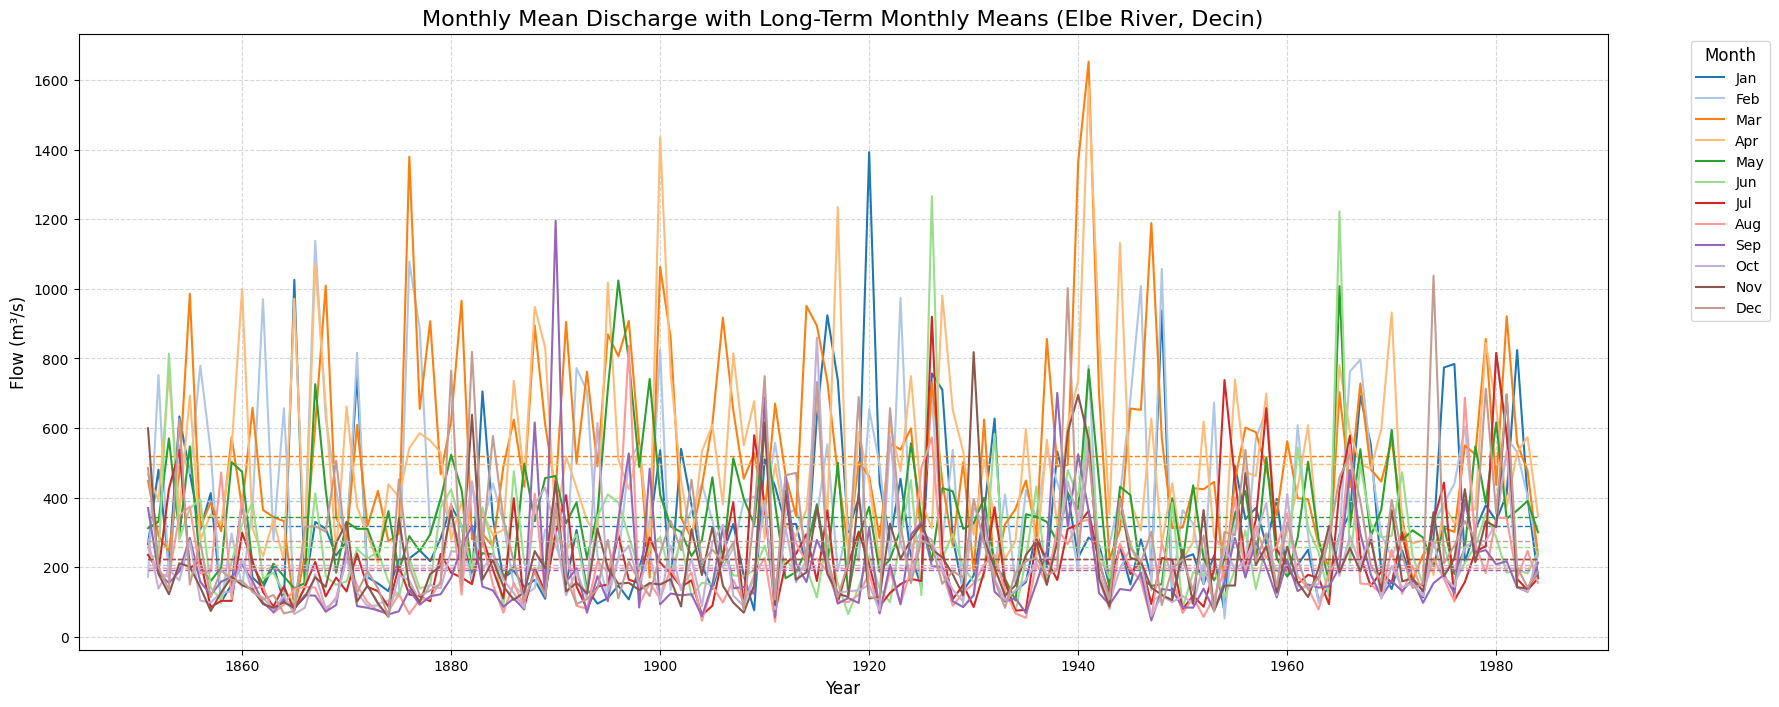

In [23]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Color palette with 12 distinct colors
colors = cm.tab20.colors

plt.figure(figsize=(22, 8))

for idx, month in enumerate(months):
    # Plot monthly discharge
    plt.plot(df["Year"], df[month], color=colors[idx], linewidth=1.5, label=month)

    # Long-term mean
    plt.hlines(avg[idx], df["Year"].min(), df["Year"].max(),
               colors=colors[idx], linestyles='--', linewidth=1)

# Titles and labels
plt.title("Monthly Mean Discharge with Long-Term Monthly Means (Elbe River, Decin)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Flow (m³/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Legend outside
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left",
           fontsize=10, title_fontsize=12)
plt.subplots_adjust(right=0.82)

plt.show()

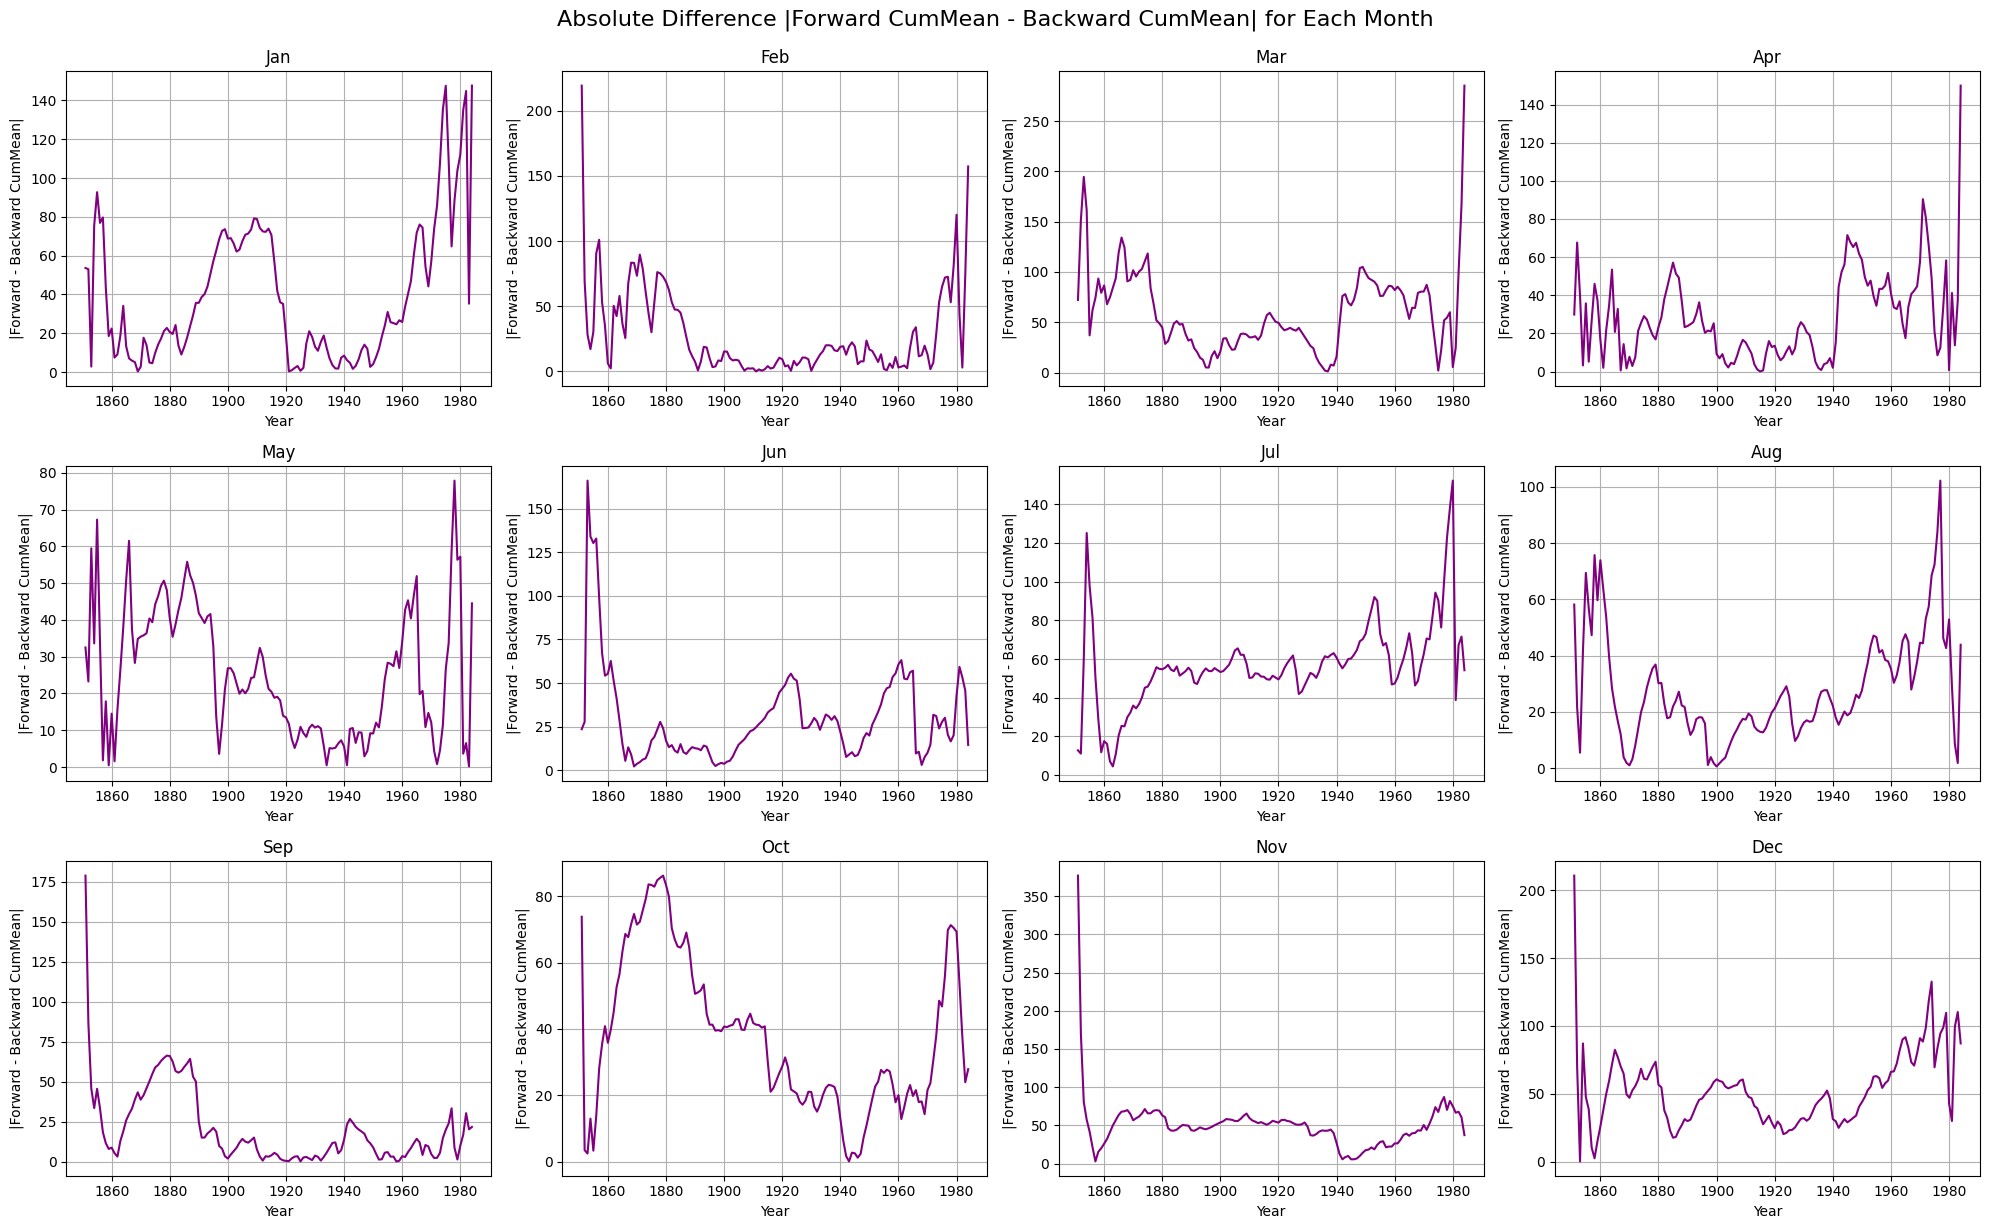

In [ ]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()  # flatten to index easily

for idx, month in enumerate(months):
    data = df[month]

    # Forward cumulative mean
    forward_cummean = data.expanding().mean()

    # Backward cumulative mean
    backward_cummean = data[::-1].expanding().mean()[::-1]

    # Absolute difference
    abs_diff = (forward_cummean - backward_cummean).abs()

    # Plot in corresponding subplot
    axes[idx].plot(df["Year"], abs_diff, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("|Forward - Backward CumMean|")
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle("Absolute Difference |Forward CumMean - Backward CumMean| for Each Month", fontsize=16, y=1.02)
plt.show()

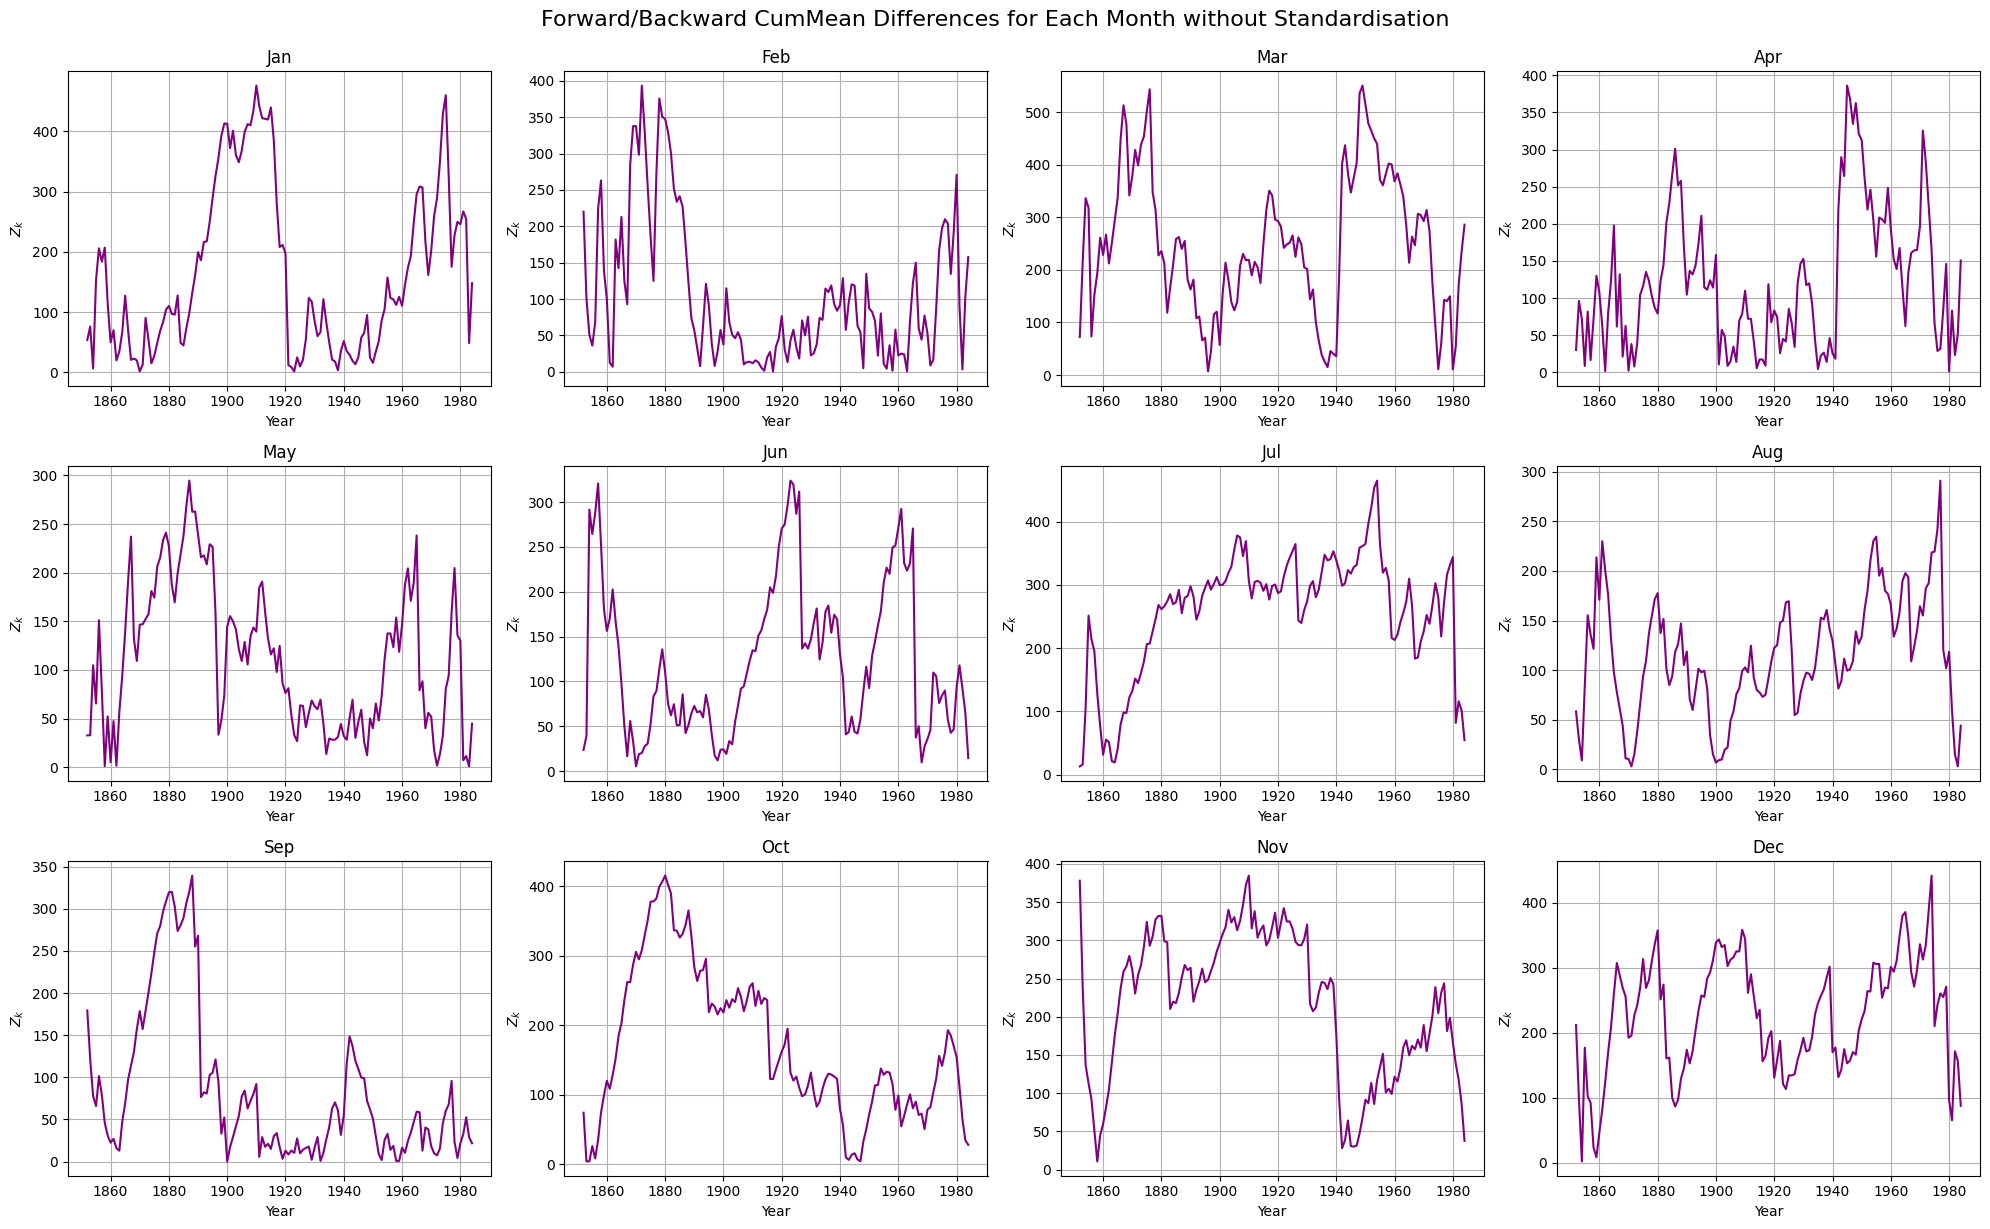

In [ ]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month].values

    Z = []
    for k in range(1, N):  # from year 1 to N-1
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        # Simplified standardized statistic
        Zk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean)
        Z.append(Zk)

    # Plot Z_k vs Year
    axes[idx].plot(df["Year"][1:], Z, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$Z_k$")
    # axes[idx].axhline(y=1, color='red', linestyle='--', label='Threshold')
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle("Forward/Backward CumMean Differences for Each Month without Standardization", fontsize=16, y=1.02)
plt.show()

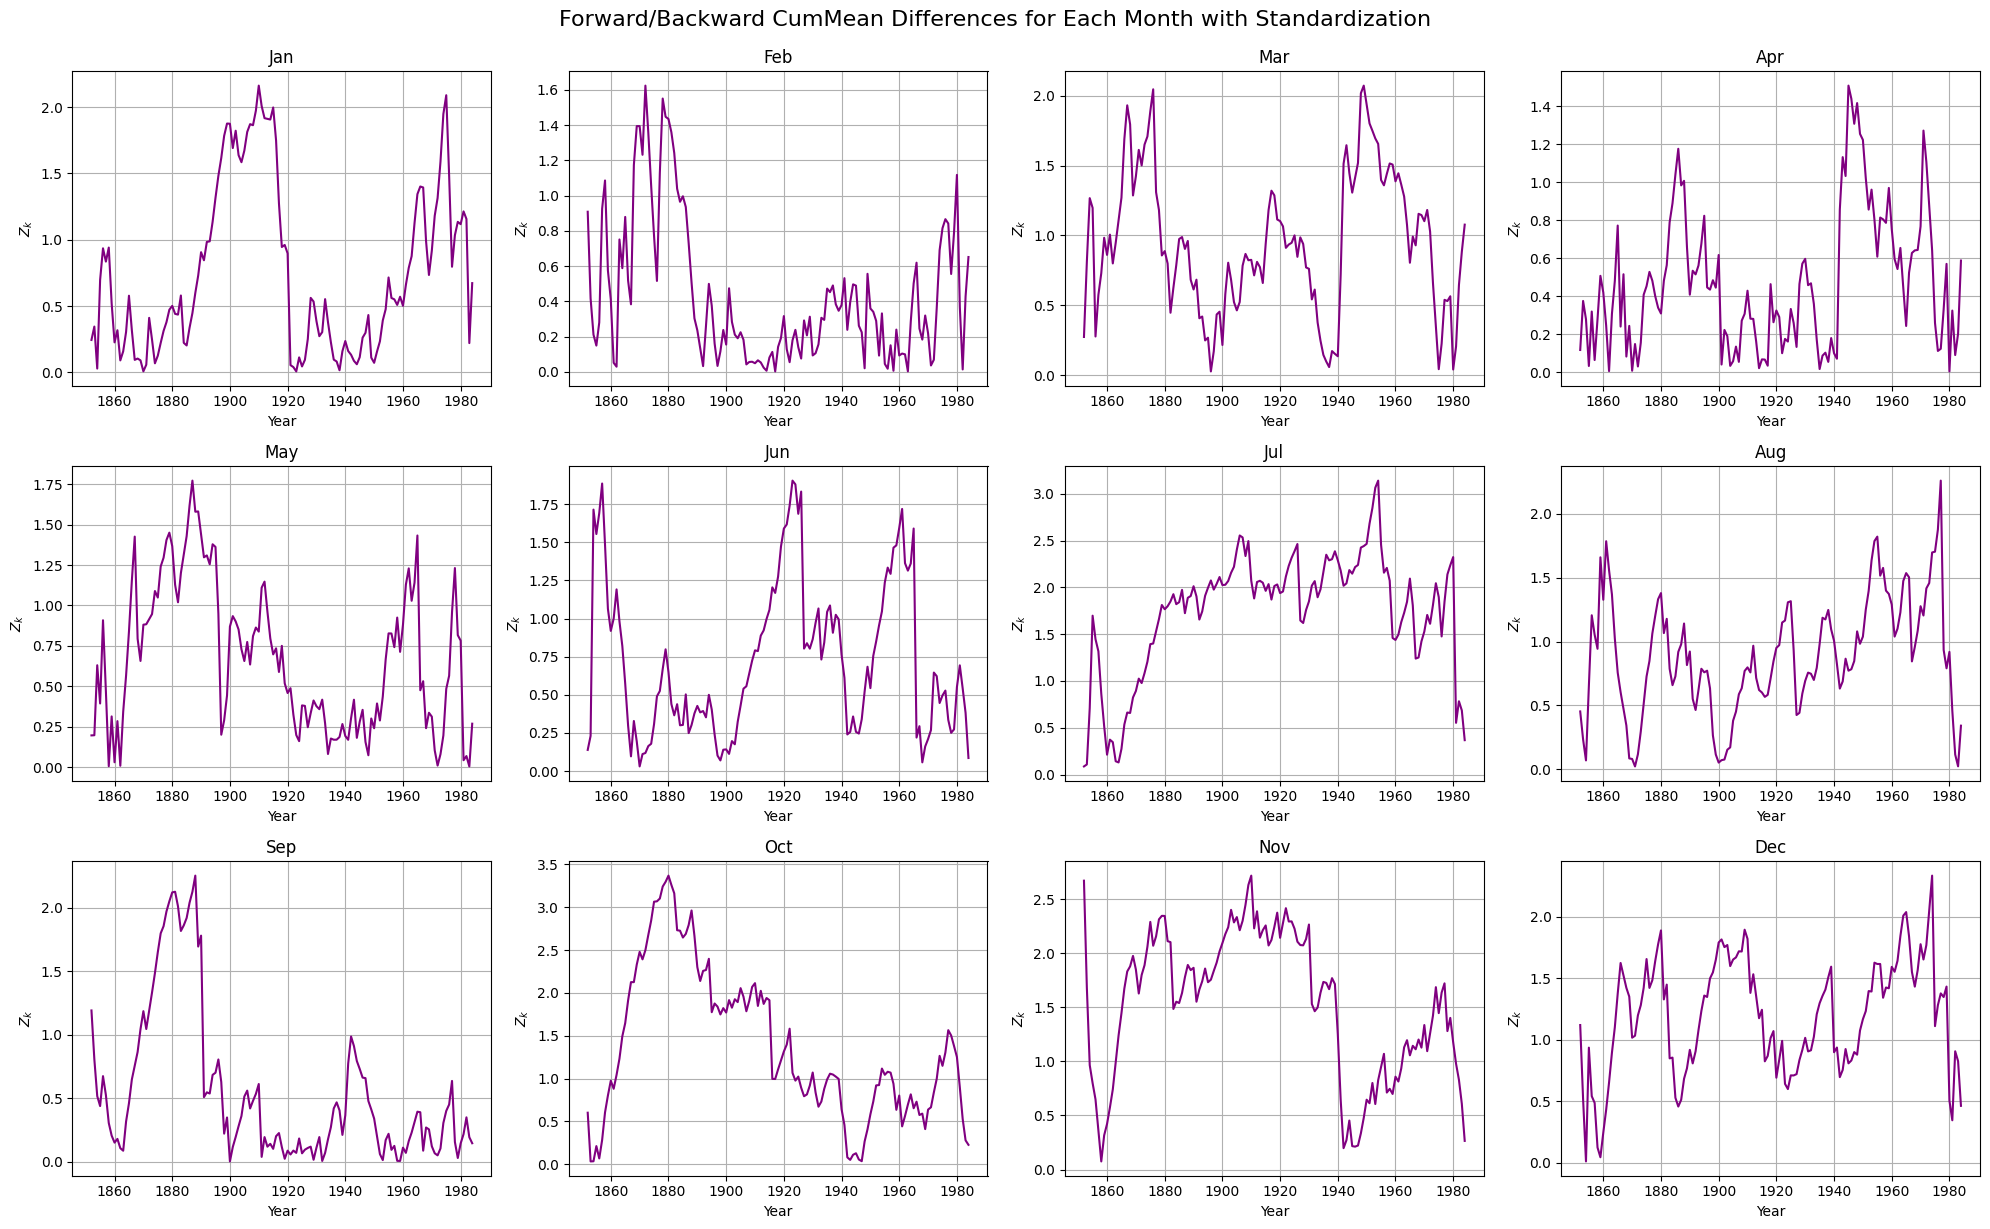

In [25]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month].values
    sigma = std_dev[idx]

    Z = []
    for k in range(1, N):
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        # Proper standardized Z_k
        Zk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean) / sigma
        Z.append(Zk)

    # Plot Z_k vs Year
    axes[idx].plot(df["Year"][1:], Z, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$Z_k$")
    # axes[idx].axhline(y=1, color='red', linestyle='--', label='Threshold')
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle("Forward/Backward CumMean Differences for Each Month with Standardization", fontsize=16, y=1.02)
plt.show()

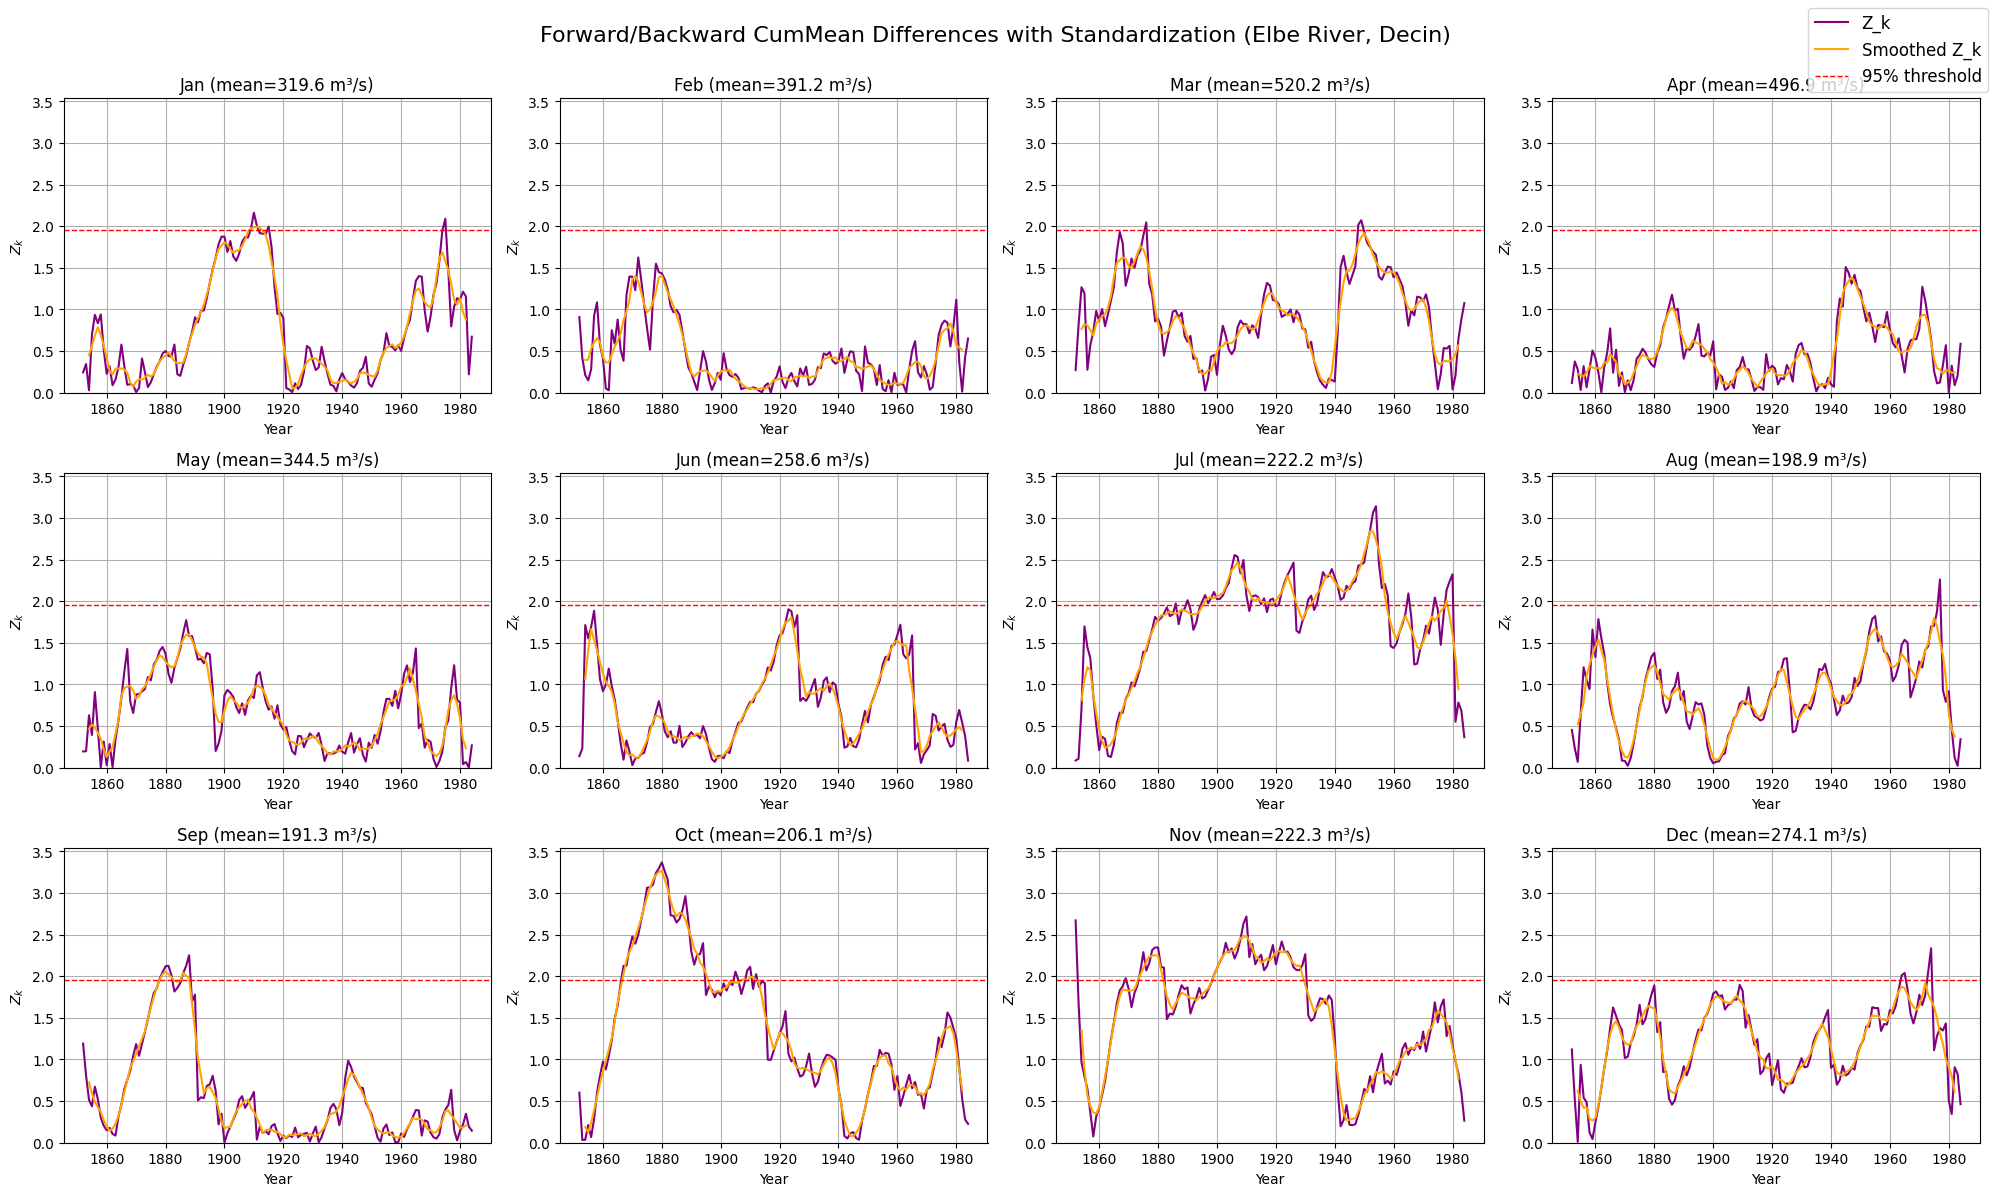

In [42]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
max_Z = 0

# Compute max Z for uniform Y-axis
max_Z = 0
for idx, month in enumerate(months):
    data = df[month].values
    sigma = std_dev[idx]

    Z = []
    for k in range(1, N):
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        # Proper standardized Z_k
        Zk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean) / sigma
        Z.append(Zk)

    max_Z = max(max_Z, max(Z))


for idx, month in enumerate(months):
    data = df[month].values
    sigma = std_dev[idx]

    Z = []
    for k in range(1, N):
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        # Proper standardized Z_k
        Zk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean) / sigma
        Z.append(Zk)

    # Plot Z_k
    axes[idx].plot(df["Year"][1:], Z, color='purple', linewidth=1.5, label='Z_k')

    # Optional smoothed Z_k
    Z_smooth = pd.Series(Z).rolling(window=5, center=True).mean()
    axes[idx].plot(df["Year"][1:], Z_smooth, color='orange', linewidth=1.5, label='Smoothed Z_k')

    # Horizontal 95% threshold
    axes[idx].axhline(1.96, color='red', linestyle='--', linewidth=1, label='95% threshold')

    axes[idx].set_title(f"{month} (mean={df[month].mean():.1f} m³/s)")
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$Z_k$")
    axes[idx].grid(True)

    # Uniform y-axis for easier seasonal comparison
    axes[idx].set_ylim(0, max_Z * 1.05)

plt.tight_layout(rect=[0,0,1,0.95])
plt.suptitle("Forward/Backward CumMean Differences with Standardization (Elbe River, Decin)", fontsize=16)

# Figure-level legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=12)

plt.show()


In [58]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# --- Pettitt Test Function ---
def pettitt_test(x):
    """
    Perform Pettitt change-point test for a 1D array x.
    Returns:
        change_point: index of detected change point (0-based)
        K: test statistic
        p: approximate p-value
    """
    N = len(x)
    ranks = rankdata(x)  # rank the data
    # Compute U_t for t = 1 to N-1
    U = np.array([2*np.sum(ranks[:t]) - t*(N+1) for t in range(1, N)])
    K = np.max(np.abs(U))  # max of |U|
    change_point = np.argmax(np.abs(U)) + 1  # +1 because t starts at 1
    p = 2 * np.exp(-6 * K**2 / (N**3 + N**2))  # approximate p-value
    return change_point, K, p

# --- Apply Pettitt Test Month by Month ---
months = df.columns[1:-1]  # assuming first column is 'Year' and last is 'Avg Annual'
results = []

for month in months:
    data = df[month].values
    cp, K, p = pettitt_test(data)
    results.append((month, cp, K, p))

# --- Convert results to DataFrame ---
results_df = pd.DataFrame(results, columns=['Month', 'Change_Year_Index', 'K', 'p-value'])

# Add the actual year corresponding to the change-point index
results_df['Change_Year'] = results_df['Change_Year_Index'].apply(lambda x: df['Year'].iloc[x])

# Keep only relevant columns
results_df = results_df[['Month', 'Change_Year', 'K', 'p-value']]

print(results_df)


   Month  Change_Year       K   p-value
0    Jan         1910  1016.0  0.155380
1    Feb         1872   376.0  1.409472
2    Mar         1876   788.0  0.430071
3    Apr         1886   481.0  1.128045
4    May         1887   767.0  0.466276
5    Jun         1961   691.0  0.613419
6    Jul         1936  1146.0  0.077494
7    Aug         1954   929.0  0.236209
8    Sep         1888   985.0  0.181166
9    Oct         1880  1456.0  0.010524
10   Nov         1922  1402.0  0.015420
11   Dec         1900  1179.0  0.064090


In [59]:
summary = []

for i, month in enumerate(months):
    data = df[month].values
    sigma = std_dev[i]  # use index directly

    # Compute standardized Z_k
    Z = [(N / (k * (N - k)))**(-0.5) * abs(np.mean(data[:k]) - np.mean(data[k:])) / sigma
         for k in range(1, N)]
    years = df["Year"][1:]

    # Max Z_k and year
    max_idx = np.argmax(Z)
    max_year = years.iloc[max_idx]
    max_val = Z[max_idx]

    # Check if Z_k exceeds threshold
    Z_sig = max_val > 1.96

    # Pettitt result for this month
    cp_row = results_df.loc[results_df['Month'] == month].iloc[0]
    cp_year = cp_row['Change_Year']
    p_val = cp_row['p-value']
    Pettitt_sig = p_val < 0.05

    # Do the two tests agree?
    agreement = "Yes" if Z_sig and Pettitt_sig else "No"

    summary.append([month, max_year, max_val, Z_sig, cp_year, p_val, Pettitt_sig, agreement])

# Make DataFrame
summary_df = pd.DataFrame(summary, columns=[
    "Month", "Max Z_k Year", "Max Z_k", "Z_k > 1.96?",
    "Pettitt Year", "Pettitt p-value", "Pettitt Sig?", "Agreement"
])

# Show the table
print(summary_df)


   Month  Max Z_k Year   Max Z_k  Z_k > 1.96?  Pettitt Year  Pettitt p-value  \
0    Jan          1910  2.161552         True          1910         0.155380   
1    Feb          1872  1.624053        False          1872         1.409472   
2    Mar          1949  2.071898         True          1876         0.430071   
3    Apr          1945  1.509406        False          1886         1.128045   
4    May          1887  1.772356        False          1887         0.466276   
5    Jun          1923  1.903511        False          1961         0.613419   
6    Jul          1954  3.140944         True          1936         0.077494   
7    Aug          1977  2.260079         True          1954         0.236209   
8    Sep          1888  2.252165         True          1888         0.181166   
9    Oct          1880  3.367792         True          1880         0.010524   
10   Nov          1910  2.717529         True          1922         0.015420   
11   Dec          1974  2.336225        

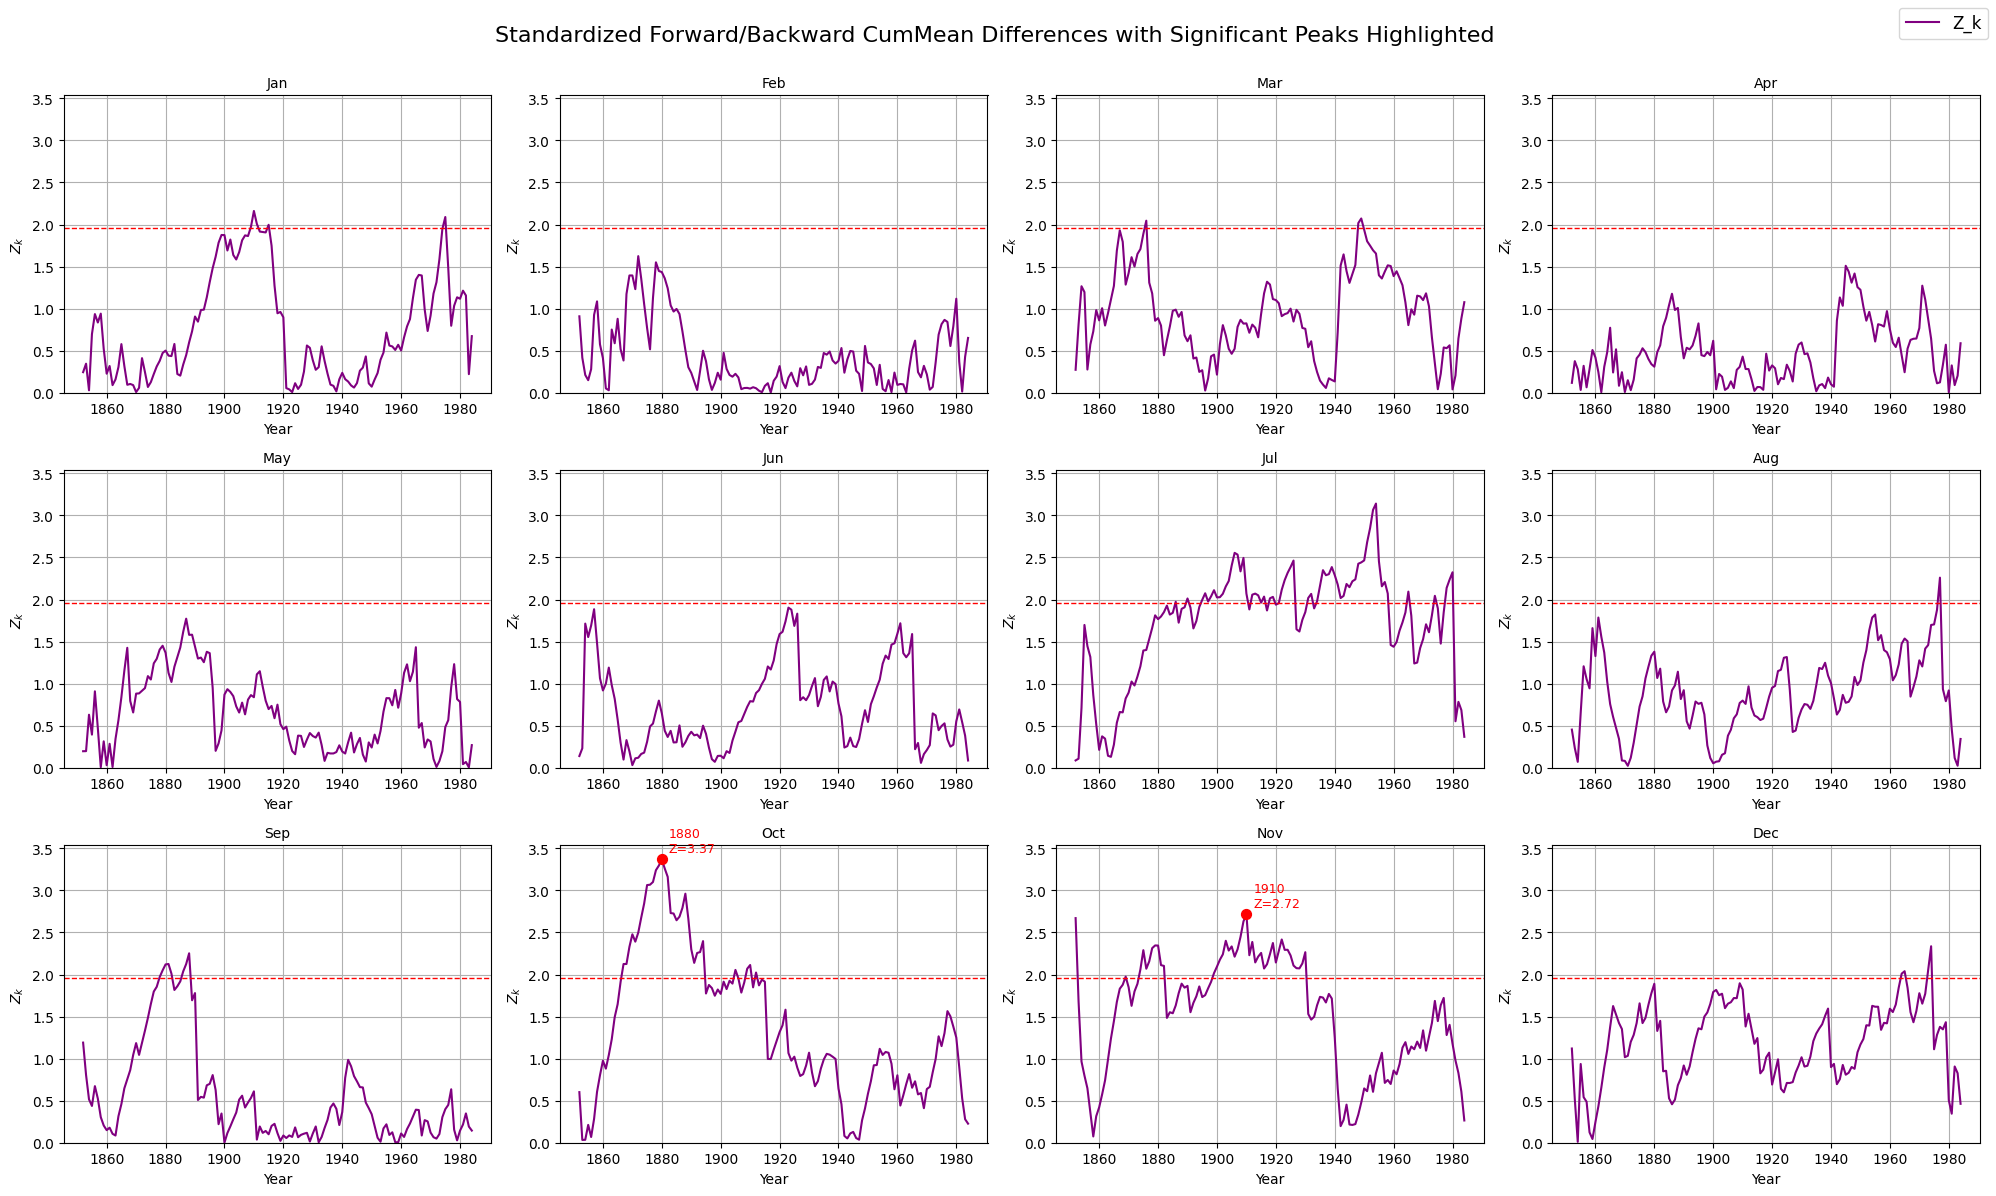

In [60]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, month in enumerate(months):
    data = df[month].values
    sigma = std_dev[i]

    # Compute standardized Z_k
    Z = [(N / (k * (N - k)))**(-0.5) * abs(np.mean(data[:k]) - np.mean(data[k:])) / sigma
         for k in range(1, N)]
    years = df["Year"][1:]

    # Plot Z_k
    axes[i].plot(years, Z, color='purple', linewidth=1.5, label='Z_k')

    # 95% significance threshold
    axes[i].axhline(1.96, color='red', linestyle='--', linewidth=1)

    # Highlight only Oct and Nov peaks with annotation
    if month in ['Oct', 'Nov']:
        max_idx = np.argmax(Z)
        peak_year = years.iloc[max_idx]
        peak_val = Z[max_idx]
        axes[i].scatter(peak_year, peak_val, color='red', s=50, zorder=5)
        axes[i].annotate(f"{peak_year}\nZ={peak_val:.2f}",
                         xy=(peak_year, peak_val),
                         xytext=(5, 5),
                         textcoords='offset points',
                         fontsize=9,
                         color='red')

    axes[i].set_title(month, fontsize=10)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(r"$Z_k$")
    axes[i].grid(True)
    axes[i].set_ylim(0, max_Z * 1.05)

plt.tight_layout(rect=[0,0,1,0.95])
plt.suptitle("Standardized Forward/Backward CumMean Differences with Significant Peaks Highlighted", fontsize=16)

# Figure-level legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=12)

plt.show()


In [61]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.9 MB/s eta 0:00:00


In [63]:
import pandas as pd
from pygam import LinearGAM, s, f
import matplotlib.pyplot as plt

# Melt the dataframe to long form
df_long = df.melt(id_vars="Year", value_vars=months,
                  var_name="Month", value_name="Discharge")

# Encode month as categorical for the model
df_long['Month_num'] = df_long['Month'].map({m: i+1 for i,m in enumerate(months)})

# Define GAM: smooth function of year + factor for month
X = df_long[['Year', 'Month_num']]
y = df_long['Discharge'].values

gam = LinearGAM(s(0) + f(1)).fit(X, y)


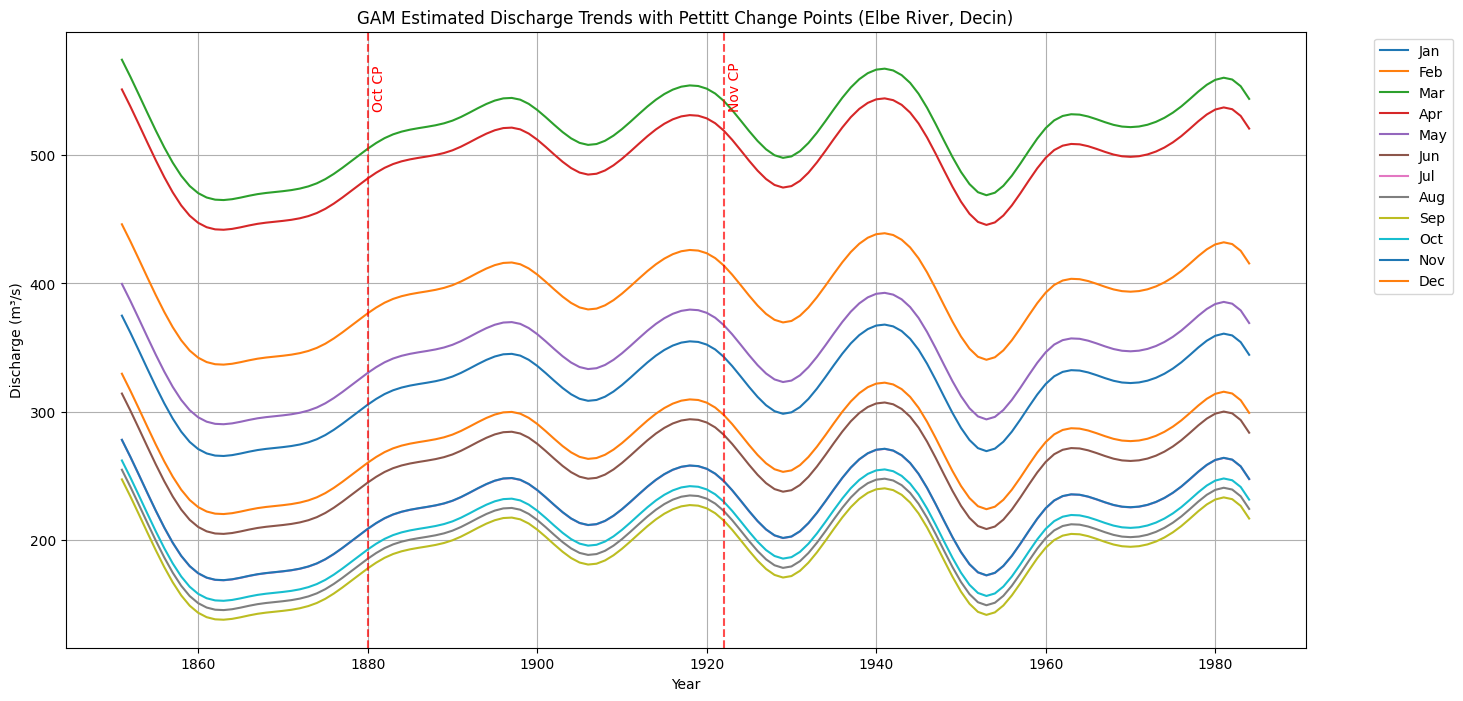

In [65]:
plt.figure(figsize=(16, 8))

years = np.arange(df['Year'].min(), df['Year'].max()+1)

# Loop through months
for i, month in enumerate(months):
    X_pred = pd.DataFrame({'Year': years, 'Month_num': [i+1]*len(years)})
    y_pred = gam.predict(X_pred)
    plt.plot(years, y_pred, label=month)

# Overlay Pettitt change points
pettitt_cp = {
    'Jan':1910,'Feb':1872,'Mar':1876,'Apr':1886,'May':1887,'Jun':1961,
    'Jul':1936,'Aug':1954,'Sep':1888,'Oct':1880,'Nov':1922,'Dec':1900
}

for month, year_cp in pettitt_cp.items():
    if month in ['Oct','Nov']:  # highlight months with significant p-values
        plt.axvline(x=year_cp, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        plt.text(year_cp+0.5, plt.ylim()[1]*0.9, f'{month} CP', rotation=90, color='red', fontsize=10)

plt.xlabel("Year")
plt.ylabel("Discharge (m³/s)")
plt.title("GAM Estimated Discharge Trends with Pettitt Change Points (Elbe River, Decin)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.show()



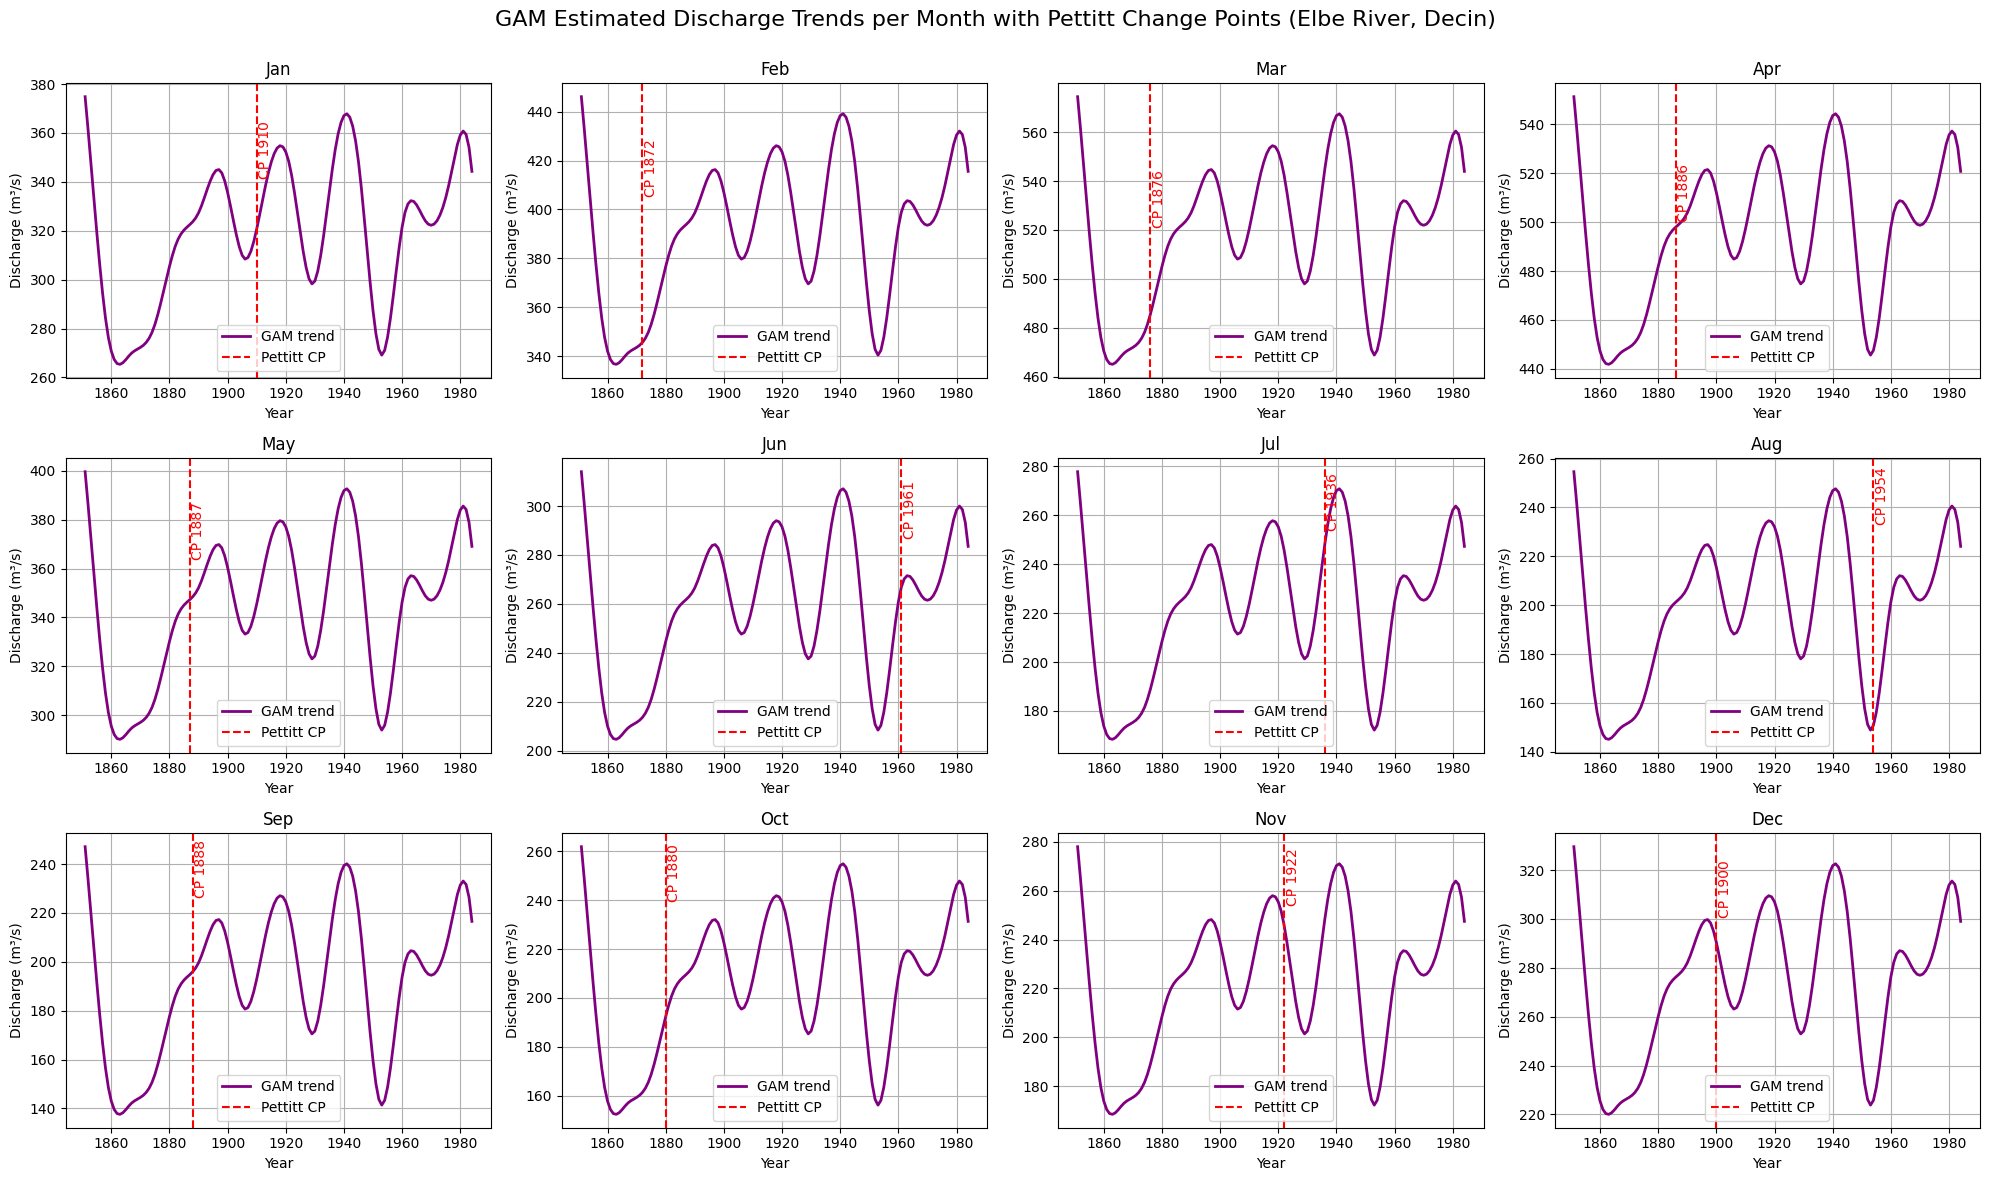

In [66]:
import matplotlib.pyplot as plt
import pandas as pd
from pygam import LinearGAM, s, f
import numpy as np

# Prepare long-form data if not already done
df_long = df.melt(id_vars="Year", value_vars=months,
                  var_name="Month", value_name="Discharge")
df_long['Month_num'] = df_long['Month'].map({m: i+1 for i,m in enumerate(months)})

# Fit GAM (smooth year + factor month)
X = df_long[['Year', 'Month_num']]
y = df_long['Discharge'].values
gam = LinearGAM(s(0) + f(1)).fit(X, y)

# Pettitt change points
pettitt_cp = {
    'Jan':1910,'Feb':1872,'Mar':1876,'Apr':1886,'May':1887,'Jun':1961,
    'Jul':1936,'Aug':1954,'Sep':1888,'Oct':1880,'Nov':1922,'Dec':1900
}

# Create 3x4 subplot
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

years = np.arange(df['Year'].min(), df['Year'].max()+1)

for i, month in enumerate(months):
    X_pred = pd.DataFrame({'Year': years, 'Month_num': [i+1]*len(years)})
    y_pred = gam.predict(X_pred)

    axes[i].plot(years, y_pred, color='purple', linewidth=2, label='GAM trend')

    # Add Pettitt change point if present
    cp_year = pettitt_cp[month]
    axes[i].axvline(cp_year, color='red', linestyle='--', linewidth=1.5, label='Pettitt CP')
    axes[i].text(cp_year+0.5, axes[i].get_ylim()[1]*0.9, f'CP {cp_year}', rotation=90,
                 color='red', fontsize=10)

    axes[i].set_title(f"{month}", fontsize=12)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Discharge (m³/s)")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout(rect=[0,0,1,0.95])
plt.suptitle("GAM Estimated Discharge Trends per Month with Pettitt Change Points (Elbe River, Decin)", fontsize=16)
plt.show()
